In [2]:
import sys
print(sys.executable)

/Users/francescodesantis/miniforge3/envs/sl_env/bin/python


In [3]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import dill
from tqdm import tqdm
from pathlib import Path
import os

In [4]:
os.getcwd()

'/Users/francescodesantis/Documents/repos/sound_localization_model/plot'

In [5]:
results_dir = '/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/sl_results/'
#'/g100_work/EIRI_E_POLIM2/desa/sound_localization_model/results/'
#'/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/sl_results/'

In [6]:
# List directory contents
items = os.listdir(results_dir)
items = sorted(items)
for item in items:
    print(item) 

clicks_1000_XXdB&TanCarney&subject_1.pic
harmonic_69dB&TanCarney&subject_1.pic
tone_0.1kHz_70dB&TanCarney&ild_only.pic
tone_0.1kHz_70dB&TanCarney&itd_only.pic
tone_0.1kHz_70dB&TanCarney&itd_only_myoga_inv.pic
tone_0.1kHz_70dB&TanCarney&itd_only_myoga_null.pic
tone_0.1kHz_70dB&TanCarney&itd_only_no_MSO_inh.pic
tone_0.1kHz_70dB&TanCarney&subject_1.pic
tone_0.1kHz_70dB&TanCarney&subject_1_myoga_inv.pic
tone_0.1kHz_70dB&TanCarney&subject_1_myoga_null.pic
tone_0.1kHz_70dB&TanCarney&subject_1_no_MSO_inh.pic
tone_0.1kHz_70dB&TanCarney&subject_2.pic
tone_0.1kHz_70dB&TanCarney&subject_3.pic
tone_0.1kHz_70dB&TanCarney&subject_4.pic
tone_0.1kHz_70dB&TanCarney&subject_5.pic
tone_0.2kHz_70dB&TanCarney&subject_1.pic
tone_0.3kHz_70dB&TanCarney&subject_1.pic
tone_0.4kHz_70dB&TanCarney&subject_1.pic
tone_0.5kHz_70dB&TanCarney&subject_1.pic
tone_0.6kHz_70dB&TanCarney&subject_1.pic
tone_0.7kHz_70dB&TanCarney&subject_1.pic
tone_0.8kHz_70dB&TanCarney&subject_1.pic
tone_0.9kHz_70dB&TanCarney&subject_1.pic
t

In [7]:
file_name = 'clicks_1000_XXdB&TanCarney&subject_1.pic'
result_path = results_dir + file_name

with open(result_path, "rb") as file:
    result = dill.load(file, ignore=True)

/Users/francescodesantis/miniforge3/envs/sl_env/lib/python3.13/site-packages/setuptools/_distutils/_msvccompiler.py:12: UserWarning: _get_vc_env is private; find an alternative (pypa/distutils#340)
  warnings.warn(


In [8]:
from analyze.report import draw_spikes_pop, draw_spikes_and_psth_bothside, draw_rate_vs_angle_pop, draw_rate_vs_angle

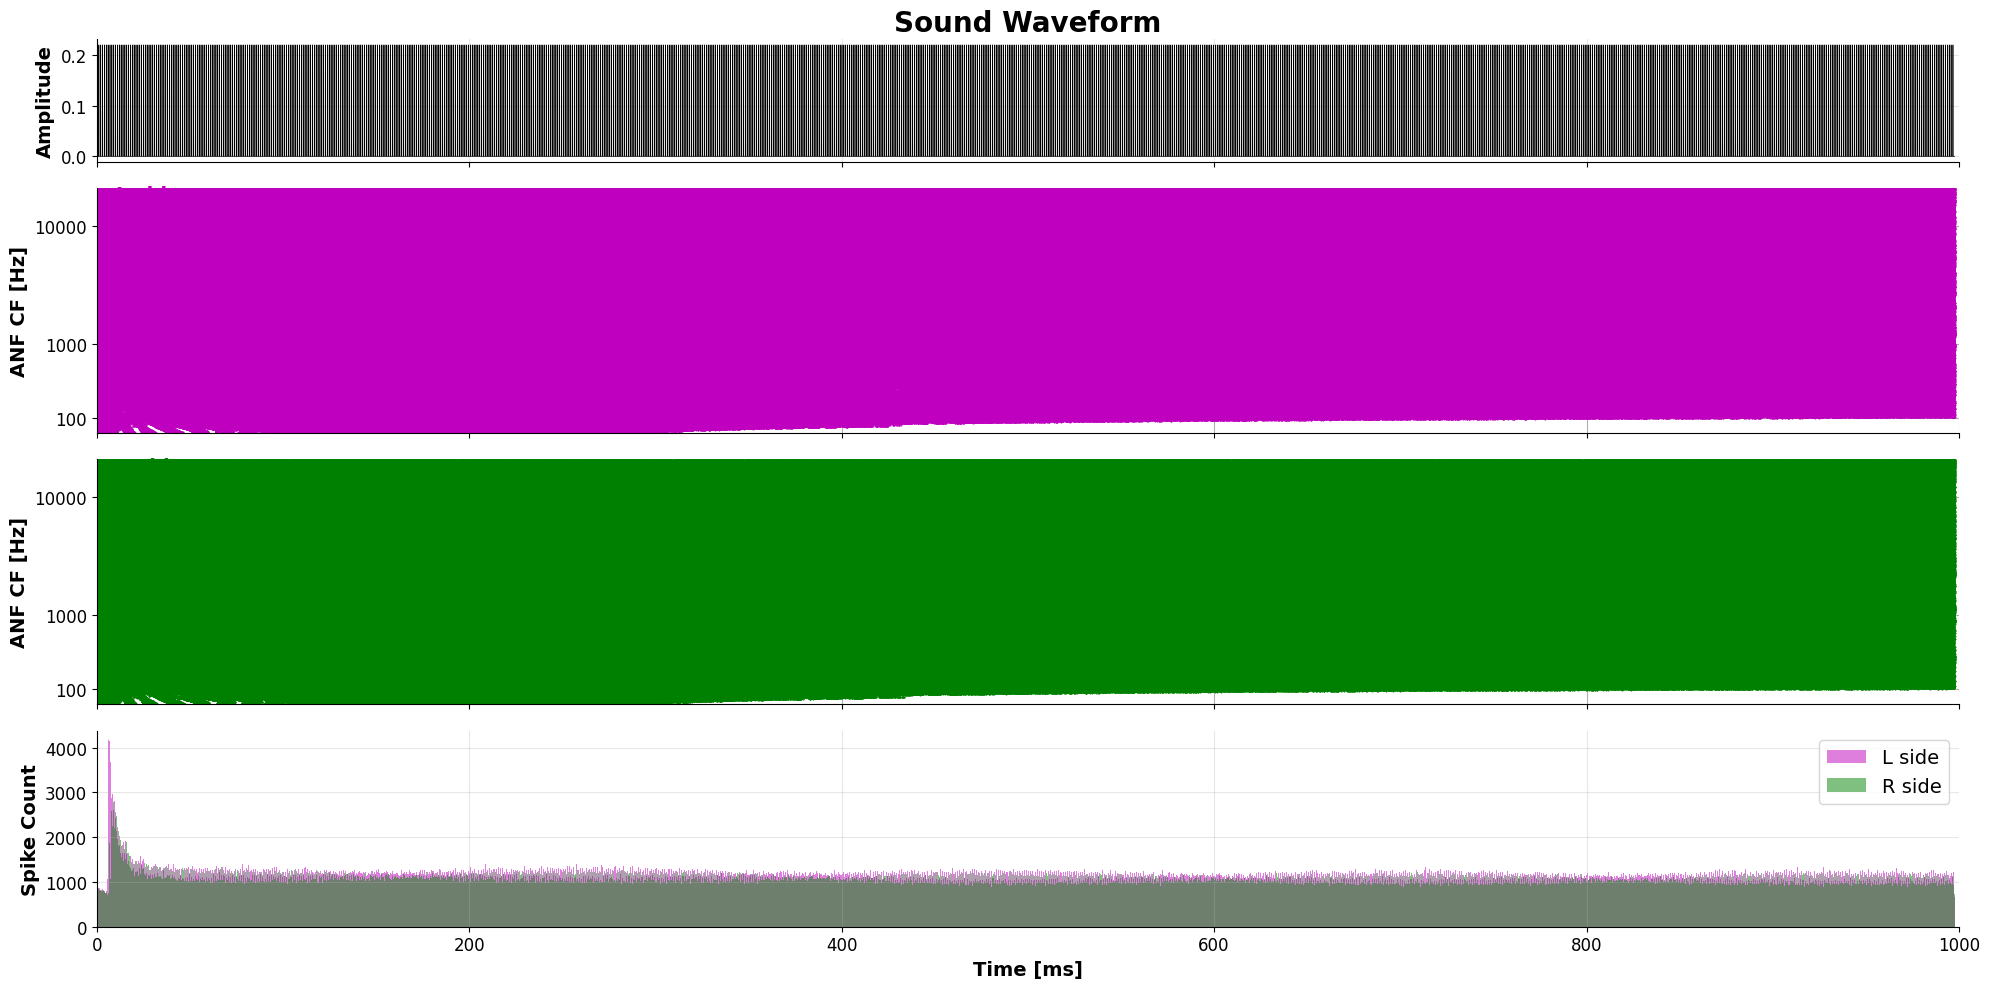

(<Figure size 2000x1000 with 4 Axes>,
 array([<Axes: title={'center': 'Sound Waveform'}, ylabel='Amplitude'>,
        <Axes: ylabel='ANF CF [Hz]'>, <Axes: ylabel='ANF CF [Hz]'>,
        <Axes: xlabel='Time [ms]', ylabel='Spike Count'>], dtype=object))

In [9]:
draw_spikes_and_psth_bothside(
    res=result,
    angle = -90,
    pop = 'ANF',
    y_ax='cf_custom', 
    plot_sound=True,
    figsize=(20,10),
    bin_size=0.5

)

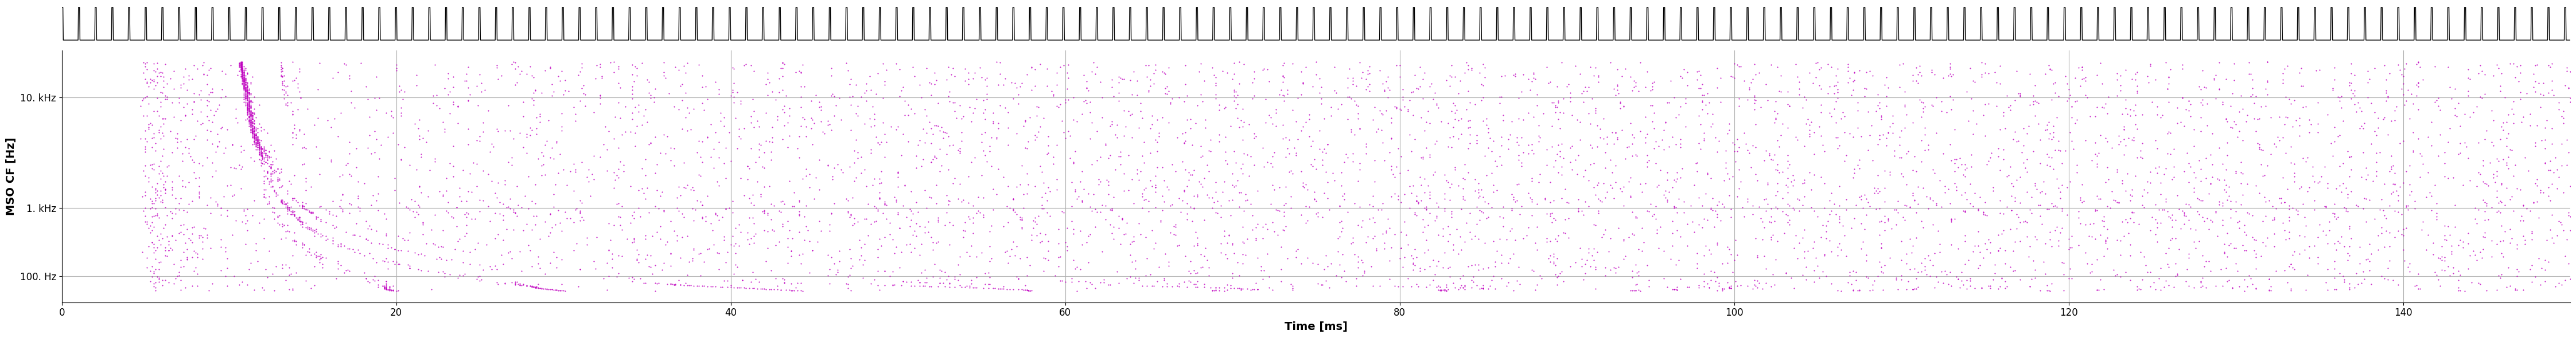

In [13]:
draw_spikes_pop(
    res=result,
    angle = 0,
    side = 'L',
    pop = 'MSO',
    y_ax='cf_custom', 
    plot_sound=True,
    xlim=(0,150),
    figsize=(45,5),
)

In [14]:
result['conf']['parameters']

{'key': 'subject_1',
 'cochlea': {'gammatone': {'hrtf_params': {'subj_number': 1,
    'ild_only': False,
    'itd_remove_strategy': 'computed'},
   'noise_factor': 0.3,
   'refractory_period': 1,
   'amplif_factor': 7},
  'ppg': {'nest': {'resolution': 0.1,
    'rng_seed': 42,
    'total_num_virtual_procs': 16}},
  'TanCarney': {'hrtf_params': {'subj_number': 1,
    'itd_remove_strategy': 'estimate_from_hrtf'},
   'cochlea_params': None,
   'rng_seed': 42,
   'omni_noise_level': 0}},
 'n_ANFs': 35000,
 'SBCs2MSOs': 5,
 'SBCs2LSOs': 5,
 'n_SBCs': 8750,
 'n_GBCs': 1750,
 'n_MSOs': 1750,
 'n_LSOs': 1750,
 'n_inhMSOs': 1750,
 'V_m': -70,
 'V_reset': -70,
 'CONFIG': {'STORE_POPS': set(),
  'NEST_KERNEL_PARAMS': {'resolution': 0.1,
   'rng_seed': 42,
   'total_num_virtual_procs': 16}},
 'DELAYS': {'GBCs2MNTBCs': 0.45,
  'GBCs2LNTBCs': 0.45,
  'SBCs2MSO_exc_ipsi': 2,
  'SBCs2MSO_exc_contra': 2,
  '_DELTA_IPSI': 0.2,
  '_DELTA_CONTRA': -0.4},
 'SYN_WEIGHTS': {'ANFs2SBCs': 35.0,
  'ANFs2GBCs': 

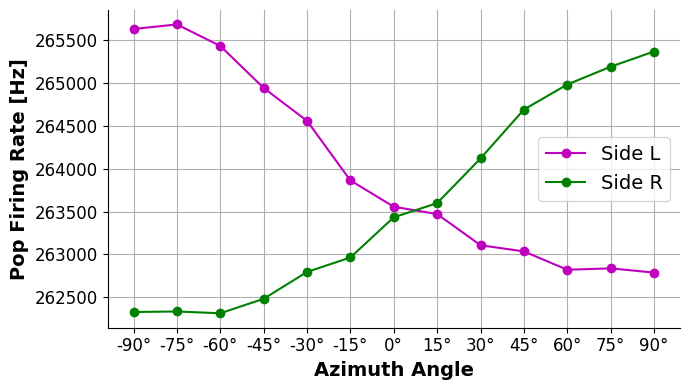

(<Axes: xlabel='Azimuth Angle', ylabel='Pop Firing Rate [Hz]'>,
 <Axes: xlabel='Azimuth Angle', ylabel='Pop Firing Rate [Hz]'>)

In [12]:
draw_rate_vs_angle_pop(
    data=result,
    pop='MSO',
    rate=False,
    norm=False
)

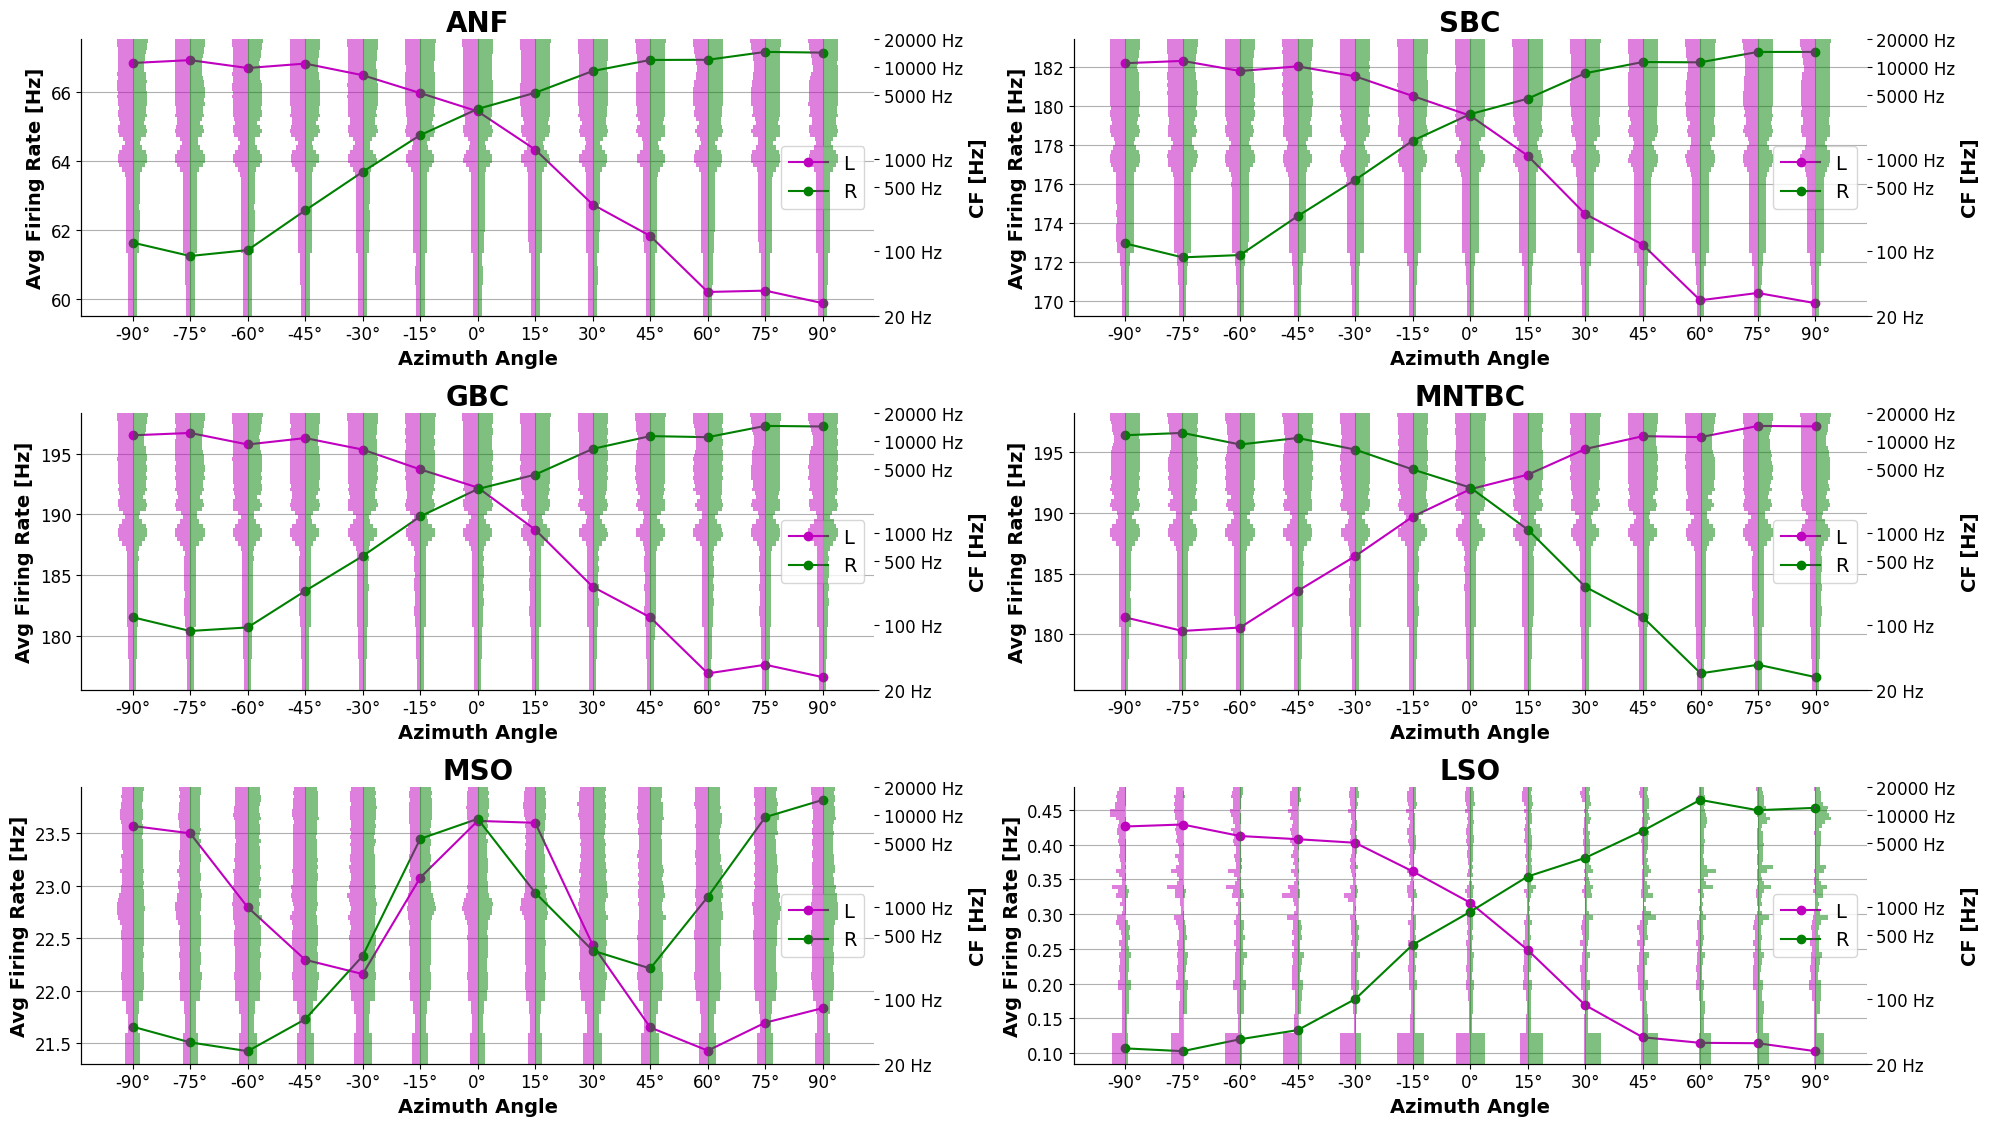

array([<Axes: title={'center': 'ANF'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'SBC'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'GBC'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'MNTBC'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'MSO'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>,
       <Axes: title={'center': 'LSO'}, xlabel='Azimuth Angle', ylabel='Avg Firing Rate [Hz]'>],
      dtype=object)

In [42]:
draw_rate_vs_angle(
    data=result,
    title="",
    rate=True, #True, False or 'diff'
)

In [18]:
result['conf'].keys()

dict_keys(['parameters', 'paths', 'model_desc', 'sound_key', 'cochlea_type'])